In [8]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)

warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio'
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                        ['CH4_start_level', 'CH4_end_level'],
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},
}

In [9]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

target_cols = ['ht', 'area', 'rt', 'start_level']

for col in target_cols:
    col = f'CH4_{col}'

    for t_type in ['std', 'air']:
        type_median = df.loc[df['type'] == t_type, col ].median()

        only_series = df[col].where(df['type']==t_type)
        df[f'last_{t_type}_{col}'] = only_series.ffill().shift(1).fillna(type_median)

for col in ['CH4_ht', 'CH4_area', 'CH4_rt', 'CH4_start_level']:
    df[f'{col}_to_last_std_ratio'] = df[col] / (df[f'last_std_{col}'] + 1e-7)
    df[f'{col}_to_last_air_ratio'] = df[col] / (df[f'last_air_{col}'] + 1e-7)

df['duration_rt_ratio'] = (df['CH4_end_time'] -df['CH4_start_time'])/df['CH4_rt']
df['rt_position'] = (df['CH4_rt'] - df['CH4_start_time']) / df['CH4_w']
df['baseline_slope'] =(df['CH4_end_level'] -df['CH4_start_level'])/df['CH4_w']
df['level_area_ratio'] = np.maximum(df['CH4_end_level'],df['CH4_start_level'] )/(df['CH4_area']+1e-7)

#  Label1


#=====================ml PART

In [10]:
target ='label1'

In [11]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'last_std_CH4_ht', 'last_air_CH4_ht',
       'last_std_CH4_area', 'last_air_CH4_area', 'last_std_CH4_rt',
       'last_air_CH4_rt', 'last_std_CH4_start_level',
       'last_air_CH4_start_level', 'CH4_ht_to_last_std_ratio',
       'CH4_ht_to_last_air_ratio', 'CH4_area_to_last_std_ratio',
       'CH4_area_to_last_air_ratio', 'CH4_rt_to_last_std_ratio',
       'CH4_rt_to_last_air_ratio', 'CH4_start_level_to_last_std_ratio',
       'CH4_start_level_to_last_air_ratio', 'duration_rt_ratio', 'rt_position',
       'baseline_slope', 'level_area_ratio'],
      dtype='object')


,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,CH4_ht_to_last_std_ratio,CH4_ht_to_last_air_ratio,CH4_area_to_last_std_ratio,CH4_area_to_last_air_ratio,CH4_rt_to_last_std_ratio,CH4_rt_to_last_air_ratio,CH4_start_level_to_last_std_ratio,CH4_start_level_to_last_air_ratio,duration_rt_ratio,rt_position,baseline_slope,level_area_ratio
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,152438.5,1349499.0,1375336.0,98.6,98.6,24223.0,24253.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,0.000000,0.000000e+00,NaN,NaN,NaN,0.000000
1994-02-16 14:49:00,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,0.0,1349499.0,0.0,98.6,0.0,24223.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,0.000000,0.000000e+00,NaN,NaN,NaN,0.000000
1994-02-16 15:09:00,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0,151205.0,0.0,1349499.0,0.0,98.6,0.0,24223.0,0.0,1.262577,1.909080e+12,0.367870,4.964400e+12,1.11359,1.098000e+09,0.415432,1.006300e+11,0.304189,3.000000,-13.076923,0.020270
1994-02-16 15:29:00,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0,151205.0,190908.0,1349499.0,496440.0,98.6,109.8,24223.0,10063.0,1.003055,7.944507e-01,0.789909,2.147252e+00,0.96146,8.633880e-01,4.128267,9.937295e+00,0.451477,1.255474,0.000000,0.093809
1994-02-16 18:00:00,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,151667.0,1349499.0,1065982.0,98.6,94.8,24223.0,99999.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,0.000000,0.000000e+00,NaN,NaN,NaN,0.000000


In [12]:
feature_ml = ['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',]

In [ ]:
from pulearn import ElkanotoPuClassifier
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()

X_train_final  = X_train_final [feature_ml]

print(X_train_final.columns)
X_test_final = tsfe.transform(X_test)
X_test_final  = X_test_final [feature_ml]
y_test_final = y_test.copy()

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       ...
       'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
       'CH4_ht_diff_1_CH4_ht_lag_1_per_change', 'CH4_w_relative_per_2h',
       'CH4_w_relative_per_7h', 'CH4_ht_relative_per_2h',
       'CH4_ht_relative_per_7h', 'CH4_w_3h_zcore_res_gen', 'CH4_w_per_rank_7D',
       'CH4_skew_per_rank_7D', 'CH4_ht_per_rank_7D'],
      dtype='object', length=218)


In [14]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21442, number of negative: 600338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7461
[LightGBM] [Info] Number of data points in the train set: 621780, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034485 -> initscore=-3.332141
[LightGBM] [Info] Start training from score -3.332141
[LightGBM] [Info] Number of positive: 17180, number of negative: 480244
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7466
[LightGBM] [Info] Number of data points in the train set: 497424, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034538 -> initscore=-3.330548
[LightGBM] [Info] Start training from score -3.330548


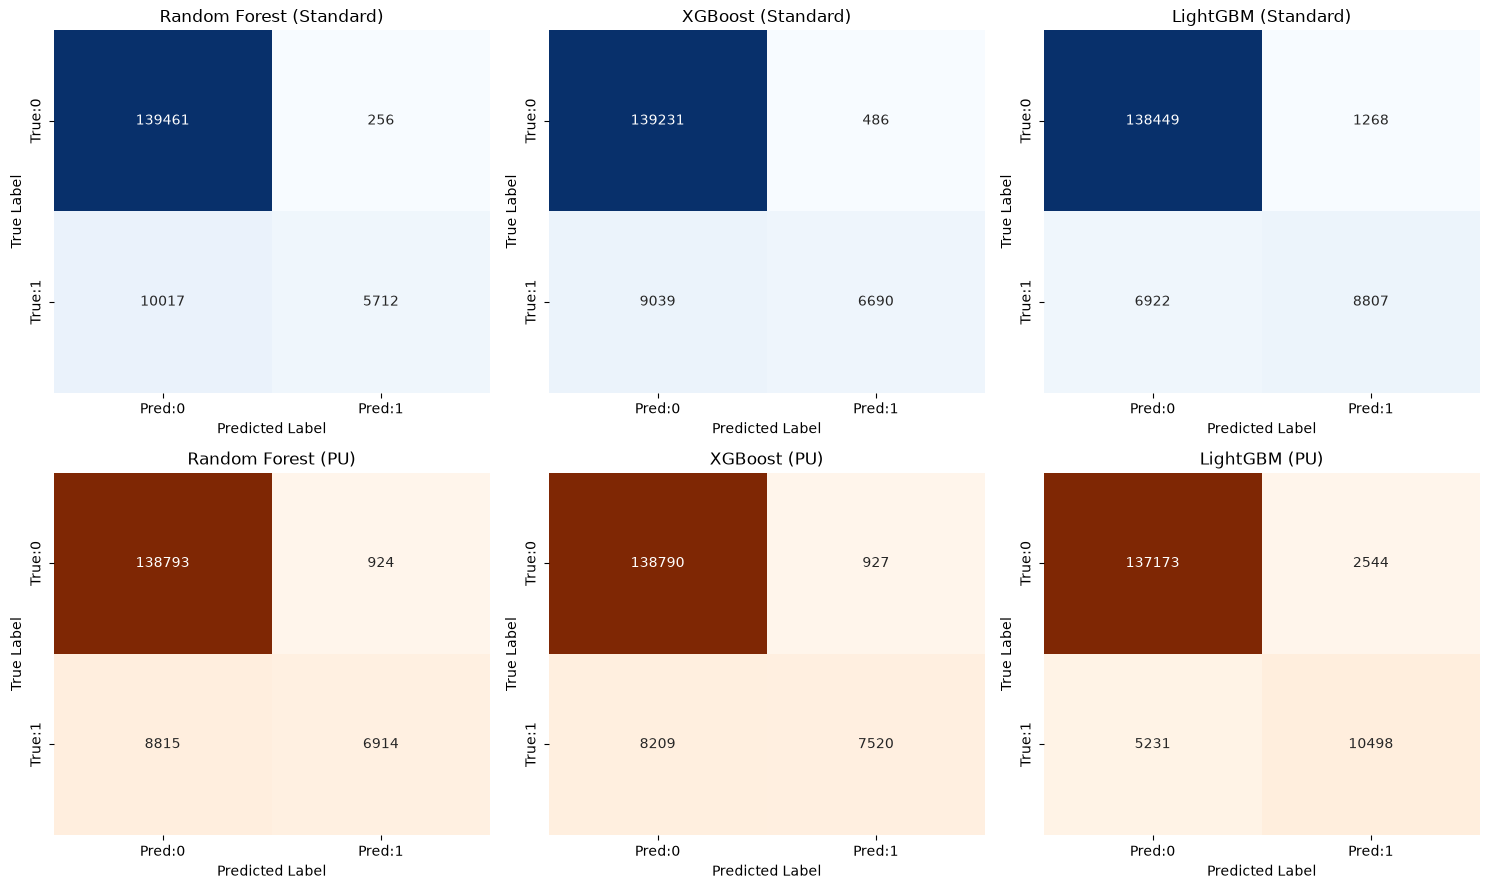

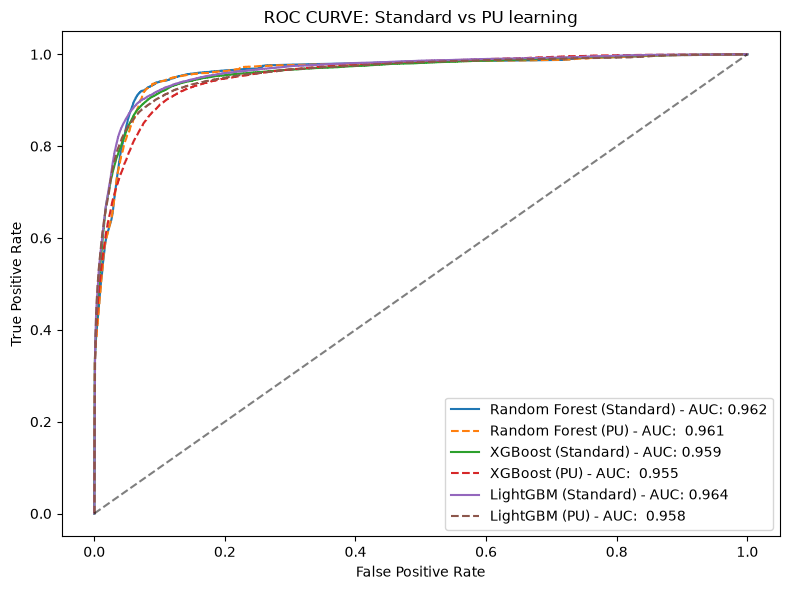

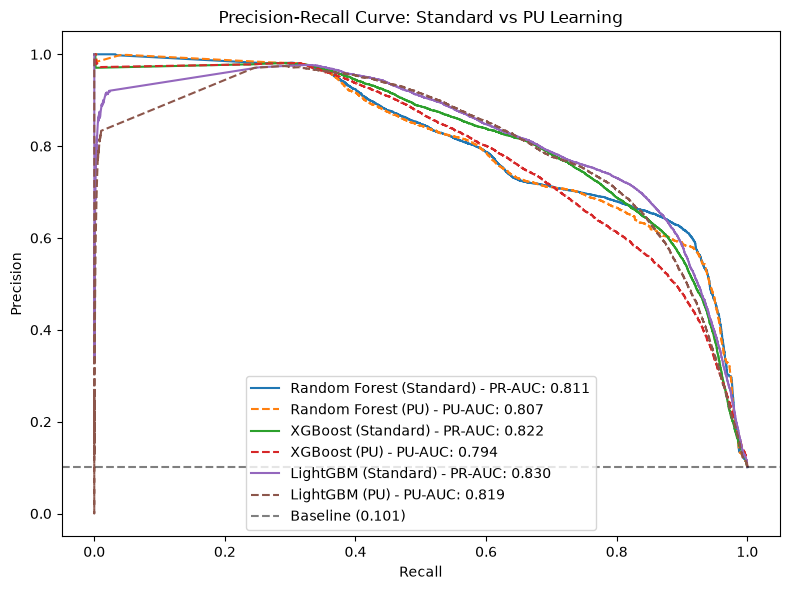

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.8   0.9619  0.8112     0.9571  0.3632    0.5265
Random Forest PU Learning        0.8   0.9607  0.8072     0.8821  0.4396    0.5868
      XGBoost    Standard        0.8   0.9595  0.8220     0.9323  0.4253    0.5842
      XGBoost PU Learning        0.8   0.9547  0.7938     0.8903  0.4781    0.6221
     LightGBM    Standard        0.8   0.9641  0.8301     0.8741  0.5599    0.6826
     LightGBM PU Learning        0.8   0.9584  0.8193     0.8049  0.6674    0.7298


In [23]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree = 0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree = 0.8,
    n_jobs=-1,
    random_state = 42,

)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train_final)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test_final, y_prob_std)
    pr_auc_std = average_precision_score(y_test_final, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test_final, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test_final, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test_final, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test_final, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test_final, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test_final, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model

    pu_clf = ElkanotoPuClassifier(
    estimator=clone(base_clf),
    hold_out_ratio=0.2
    )
    
    pu_clf.fit(X_train_final, y_train_final)

    y_prob_pu = pu_clf.predict_proba(X_test_final)[:, 1]
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test_final, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test_final, y_prob_pu)
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test_final, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test_final, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test_final, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test_final, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test_final, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test_final, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("image/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test_final == 1) / len(y_test_final)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("image/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("image/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("image/PU_vs_Standard_Metrics.csv", index=False)
#===========

#============ threshold

In [26]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree = 0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate = 0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree = 0.8,
    n_jobs=-1,
    random_state = 42,

)
} 


fixed_threshold = 0.8
threshold_candi = np.linspace(0.01, 0.99, 99)
comparison_results = []
def get_best_threshold(y_true, y_prob):
    best_thresh = 0.5
    best_f1 = -1
    best_prec = 0
    best_rec = 0

    for thresh in threshold_candi:
        y_pred = (y_prob >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_prec = precision_score(y_true, y_pred, zero_division=0)
            best_rec = recall_score(y_true, y_pred, zero_division=0)


    return best_thresh, best_prec, best_rec, best_f1


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train_final)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]

    y_pred_std_fixed = (y_prob_std >= fixed_threshold).astype(int)
    f1_std_fixed = f1_score(y_test_final, y_pred_std_fixed, zero_division=0)
    prec_std_fixed = precision_score(y_test_final, y_pred_std_fixed, zero_division=0)
    rec_std_fixed = recall_score(y_test_final, y_pred_std_fixed, zero_division=0)

    best_thresh_std, prec_std_opt, rec_std_opt, f1_std_opt = get_best_threshold(y_test_final, y_prob_std)


    comparison_results.append({
        "Model":name, "Type":"Standard", 
        "Ori Threshold":threshold,
        "Ori F1": round(f1_std_fixed, 4),
        "Best Thresh": round(best_thresh_std, 2),
        "Opt Precision":round(prec_std_opt, 4),
        "Opt Precision": round(prec_std_opt, 4),
        "Opt Recall": round(rec_std_opt, 4),
        "Opt F1": round(f1_std_opt, 4),
        "F1 Gain": round(f1_std_opt-f1_std_fixed, 4),
    })

    #============= Pu model

    pu_clf = ElkanotoPuClassifier(
    estimator=clone(base_clf),
    hold_out_ratio=0.2
    )
    
    pu_clf.fit(X_train_final, y_train_final)

    y_prob_pu = pu_clf.predict_proba(X_test_final)[:, 1]

    y_pred_pu_fixed = (y_prob_pu >= fixed_threshold).astype(int)
    f1_pu_fixed = f1_score(y_test_final, y_pred_pu_fixed, zero_division=0)
    prec_pu_fixed = precision_score(y_test_final, y_pred_pu_fixed, zero_division=0)
    rec_pu_fized = recall_score(y_test_final, y_pred_pu_fixed, zero_division=0)


    best_thresh_pu, prec_pu_opt, rec_pu_opt, f1_pu_opt = get_best_threshold(y_test_final, y_prob_pu)

    comparison_results.append({
        "Model":name, "Type":"PU Learning", 
        "Ori Threshold":fixed_threshold,
        "Ori F1": round(f1_pu_fixed, 4),
        "Best Thresh": round(best_thresh_pu, 2),
        "Opt Precision":round(prec_pu_opt, 4),
        "Opt Precision": round(prec_pu_opt, 4),
        "Opt Recall": round(rec_pu_opt, 4),
        "Opt F1": round(f1_pu_opt, 4),
        "F1 Gain": round(f1_pu_opt-f1_pu_fixed, 4),
    })

df_metrics = pd.DataFrame(comparison_results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("image/PU_vs_Standard_Metrics.csv", index=False)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21442, number of negative: 600338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7461
[LightGBM] [Info] Number of data points in the train set: 621780, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034485 -> initscore=-3.332141
[LightGBM] [Info] Start training from score -3.332141
[LightGBM] [Info] Number of positive: 17072, number of negative: 480352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7449
[LightGBM] [Info] Number of data points in the train set: 497424, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034321 -> initscore=-3.33707

In [30]:
df_metrics

,Model,Type,Ori Threshold,Ori F1,Best Thresh,Opt Precision,Opt Recall,Opt F1,F1 Gain
0,Random Forest,Standard,0.8,0.5265,0.07,0.6491,0.8620,0.7406,0.2141
1,Random Forest,PU Learning,0.8,0.5873,0.12,0.6587,0.8364,0.7370,0.1497
2,XGBoost,Standard,0.8,0.5842,0.13,0.7443,0.7475,0.7459,0.1617
3,XGBoost,PU Learning,0.8,0.6227,0.11,0.7021,0.7760,0.7372,0.1145
4,LightGBM,Standard,0.8,0.6826,0.16,0.7199,0.8154,0.7646,0.0820
5,LightGBM,PU Learning,0.8,0.7232,0.23,0.7227,0.8003,0.7595,0.0363


import joblib
joblib.dump(pu_estimator, "pu_rf_model_0730v1.joblib")

import joblib
pu_estimator = joblib.load("pu_rf_model_0730v1.joblib")

In [28]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
)

pu_estimator = ElkanotoPuClassifier(
    estimator=base_rf,
    hold_out_ratio=0.2
)

pu_estimator.fit(X_train_final, y_train_final)

,estimator,RandomForestC...ndom_state=42)
,hold_out_ratio,0.2
,random_state,None
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.8
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100


/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


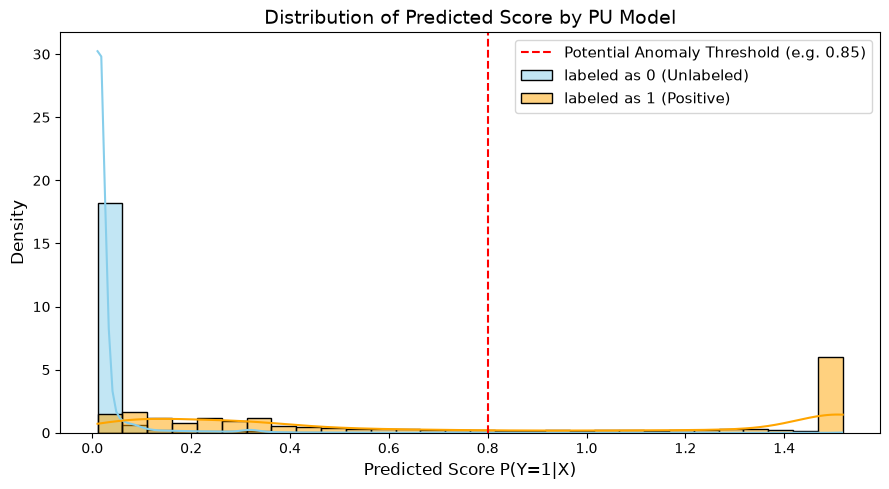

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
best_threshold = 0.8
y_probs = pu_estimator.predict_proba(X_test_final)[:,1]

probs_pos = y_probs[y_test_final == 1]
probs_unl = y_probs[y_test_final == 0]


plt.figure(figsize=(9,5))

sns.histplot(probs_unl, color='skyblue', label='labeled as 0 (Unlabeled)', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(probs_pos, color='orange', label='labeled as 1 (Positive)', kde=True, stat='density', bins=30, alpha=0.5)

plt.axvline(x=0.8, color='red', linestyle='--', label='Potential Anomaly Threshold (e.g. 0.85)')

plt.title("Distribution of Predicted Score by PU Model", fontsize=14)
plt.xlabel("Predicted Score P(Y=1|X)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("image/ PU_Probability_distribution.png")

plt.show()

#============================== 


In [13]:
threshold = 0.8

potential_anomaly_mask = (y_test_final.values==0) & (y_probs>=0.8)

potential_anomalies = X_test_final.loc[potential_anomaly_mask].copy()
potential_anomalies['pu_score'] = y_probs[potential_anomaly_mask]

potential_anomalies = potential_anomalies.sort_values(by='pu_score', ascending=False)
potential_anomalies.head(20)

,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,CH4_ht_to_last_std_ratio,CH4_ht_to_last_air_ratio,CH4_area_to_last_std_ratio,CH4_area_to_last_air_ratio,CH4_rt_to_last_std_ratio,CH4_rt_to_last_air_ratio,CH4_start_level_to_last_std_ratio,CH4_start_level_to_last_air_ratio,duration_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_area_diff_3,CH4_area_diff_6,CH4_area_diff_72,CH4_ht_diff_1,CH4_ht_diff_3,CH4_ht_diff_6,CH4_ht_diff_72,CH4_w_diff_1,CH4_w_diff_3,CH4_w_diff_6,CH4_w_diff_72,CH4_rt_diff_1,CH4_rt_diff_3,CH4_rt_diff_6,CH4_rt_diff_72,CH4_area_lag_1,CH4_area_lag_3,CH4_area_lag_6,CH4_area_lag_72,CH4_rt_lag_1,CH4_rt_lag_3,CH4_rt_lag_6,CH4_rt_lag_72,CH4_ht_lag_1,CH4_ht_lag_3,CH4_ht_lag_6,CH4_ht_lag_72,pflow_lag_1,pflow_lag_3,pflow_lag_6,pflow_lag_72,CH4_w_lag_1,CH4_w_lag_3,CH4_w_lag_6,CH4_w_lag_72,CH4_ht_CH4_ht_lag_72_diff_cross,CH4_area_CH4_area_lag_72_diff_cross,CH4_end_time_CH4_start_time_diff_cross,CH4_end_level_CH4_start_level_diff_cross,CH4_rt_pflow_diff_cross,CH4_w_roll_std_1h,CH4_w_roll_std_3h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_3D,CH4_w_roll_std_7D,CH4_ht_roll_std_1h,CH4_ht_roll_std_3h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_3D,CH4_ht_roll_std_7D,CH4_area_roll_std_1h,CH4_area_roll_std_3h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_3D,CH4_area_roll_std_7D,CH4_end_time_CH4_start_time_diff_cross_roll_std_1h,CH4_end_time_CH4_start_time_diff_cross_roll_std_3h,CH4_end_time_CH4_start_time_diff_cross_roll_std_6h,CH4_end_time_CH4_start_time_diff_cross_roll_std_24h,CH4_end_time_CH4_start_time_diff_cross_roll_std_3D,CH4_end_time_CH4_start_time_diff_cross_roll_std_7D,CH4_rt_roll_mean_1h,CH4_rt_residual_1h,CH4_rt_roll_mean_3h,CH4_rt_residual_3h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_3D,CH4_rt_residual_3D,CH4_rt_roll_mean_7D,CH4_rt_residual_7D,CH4_w_roll_mean_1h,CH4_w_residual_1h,CH4_w_roll_mean_3h,CH4_w_residual_3h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_3D,CH4_w_residual_3D,CH4_w_roll_mean_7D,CH4_w_residual_7D,CH4_ht_roll_mean_1h,CH4_ht_residual_1h,CH4_ht_roll_mean_3h,CH4_ht_residual_3h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_3D,CH4_ht_residual_3D,CH4_ht_roll_mean_7D,CH4_ht_residual_7D,CH4_area_roll_mean_1h,CH4_area_residual_1h,CH4_area_roll_mean_3h,CH4_area_residual_3h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_3D,CH4_area_residual_3D,CH4_area_roll_mean_7D,CH4_area_residual_7D,CH4_rt_roll_median_1h,CH4_rt_roll_median_3h,CH4_rt_roll_median_6h,CH4_rt_roll_median_24h,CH4_rt_roll_median_3D,CH4_rt_roll_median_7D,CH4_w_roll_median_1h,CH4_w_roll_median_3h,CH4_w_roll_median_6h,CH4_w_roll_median_24h,CH4_w_roll_median_3D,CH4_w_roll_median_7D,CH4_ht_roll_median_1h,CH4_ht_roll_median_3h,CH4_ht_roll_median_6h,CH4_ht_roll_median_24h,CH4_ht_roll_median_3D,CH4_ht_roll_median_7D,CH4_area_roll_median_1h,CH4_area_roll_median_3h,CH4_area_roll_median_6h,CH4_area_roll_median_24h,CH4_area_roll_median_3D,CH4_area_roll_median_7D,pflow_roll_median_1h,pflow_roll_median_3h,pflow_roll_median_6h,pflow_roll_median_24h,pflow_roll_median_3D,pflow_roll_median_7D,CH4_area_lag_72_roll_median_1h,CH4_area_lag_72_roll_median_3h,CH4_area_lag_72_roll_median_6h,CH4_area_lag_72_roll_median_24h,CH4_area_lag_72_roll_median_3D,CH4_area_lag_72_roll_median_7D,CH4_ht_lag_72_roll_median_1h,CH4_ht_lag_72_roll_median_3h,CH4_ht_lag_72_roll_median_6h,CH4_ht_lag_72_roll_median_24h,CH4_ht_lag_72_roll_median_3D,CH4_ht_lag_72_roll_median_7D,CH4_rt_mad_1h,CH4_rt_mad_3h,CH4_rt_mad_6h,CH4_rt_mad_24h,CH4_rt_mad_3D,CH4_rt_mad_7D,CH4_w_mad_1h,CH4_w_mad_3h,CH4_w_mad_6h,CH4_w_mad_

In [14]:
len(potential_anomalies)

464

In [15]:
potential_anomalies.to_csv("pu_anomaly_0730.csv")

===============

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


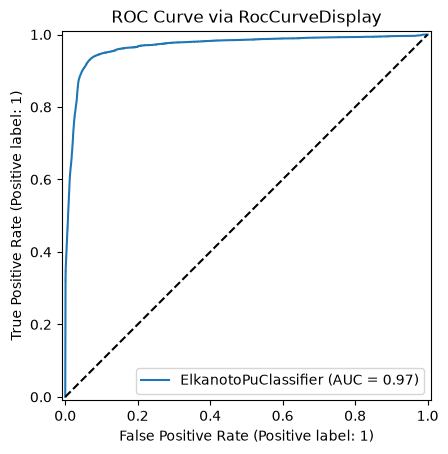

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


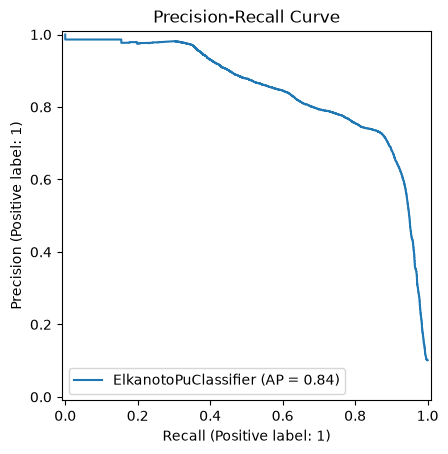

In [16]:

#=========== plotting
#======== ROC
RocCurveDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("ROC Curve via RocCurveDisplay")
plt.plot([0, 1], [0,1], 'k--') 
plt.savefig("image/ROC_Curve.png")
#mlflow.log_artifact("image/ROC_Curve.png")
plt.show()    
plt.close()
# ======= PRC 
PrecisionRecallDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("Precision-Recall Curve")
plt.savefig("image/PRC_Curve.png")
#mlflow.log_artifact("image/PRC_Curve.png")
plt.show()    
plt.close()

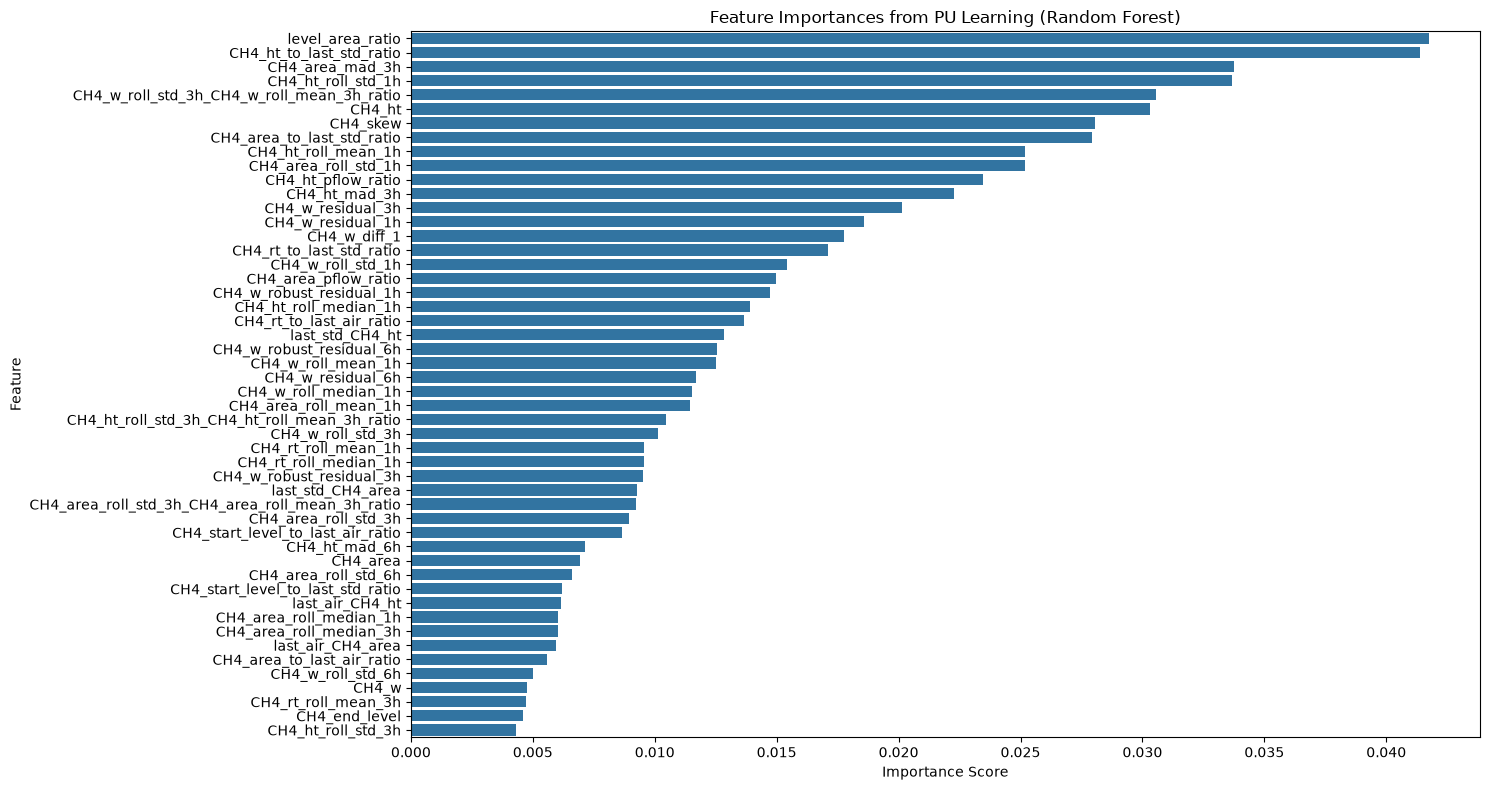

In [11]:
base_rf = pu_estimator.estimator

importances = base_rf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(50))
plt.title('Feature Importances from PU Learning (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [12]:
feature_imp_df['Feature'].tolist()

['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',
 'CH4_rt_roll_median_1h',
 'CH4_w_robust_residual_3h',
 'last_std_CH4_area',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_area_roll_std_3h',
 'CH4_start_level_to_last_air_ratio',
 'CH4_ht_mad_6h',
 'CH4_area',
 'CH4_area_roll_std_6h',
 'CH4

In [9]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]
y_prob = np.clip(y_prob, 0.0, 1.0)
y_proba_best = (y_prob >= best_threshold).astype(int)

analysis_df = pd.DataFrame({
    'original_index': X_test_final.index,
    'true_label': y_test.values,
    'predicted_label': y_proba_best,
    'predicted_prob': y_prob
}, index=X_test_final.index)

errors_df = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']].copy()

def error_type(row):
    if row['true_label'] == 1 and row['predicted_label'] == 0:
        return 'False Negative, actual 1; predicted 0, confirmed flag, but model missed'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'Potential Hidden Flag( actual 0; predicted 1; Unlabled, but high prob)'

errors_df['error_type'] = errors_df.apply(error_type, axis=1)

errors_df['severity'] = (errors_df['predicted_prob'] - best_threshold).abs()

errors_df = errors_df.join(X_test_final)

errors_df = errors_df.sort_values(by='severity', ascending=False)

print('==== ERROR SUMMARY===')
print(f'error per: {len(errors_df)/len(X_test_final):.2%}')

#errors_df.to_csv('error_analysis_with_index.csv', index=True)#=========
fp_flag_df = errors_df[errors_df['error_type'].str.contains('Potential Hidden Flag')].copy()

fp_flag_df.head(20)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


==== ERROR SUMMARY===
error per: 7.94%


,original_index,true_label,predicted_label,predicted_prob,error_type,severity,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_w_diff_1,CH4_area_lag_1,CH4_rt_lag_1,CH4_ht_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_w_roll_std_40min,CH4_w_roll_std_2h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_2D,CH4_end_time_roll_std_40min,CH4_end_time_roll_std_2h,CH4_end_time_roll_std_6h,CH4_end_time_roll_std_24h,CH4_end_time_roll_std_2D,CH4_ht_roll_std_40min,CH4_ht_roll_std_2h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_2D,CH4_area_roll_std_40min,CH4_area_roll_std_2h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_2D,CH4_rt_roll_mean_40min,CH4_rt_residual_40min,CH4_rt_roll_mean_2h,CH4_rt_residual_2h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_2D,CH4_rt_residual_2D,CH4_w_roll_mean_40min,CH4_w_residual_40min,CH4_w_roll_mean_2h,CH4_w_residual_2h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_2D,CH4_w_residual_2D,CH4_ht_roll_mean_40min,CH4_ht_residual_40min,CH4_ht_roll_mean_2h,CH4_ht_residual_2h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_2D,CH4_ht_residual_2D,CH4_area_roll_mean_40min,CH4_area_residual_40min,CH4_area_roll_mean_2h,CH4_area_residual_2h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_2D,CH4_area_residual_2D,CH4_end_time_CH4_start_time_diff_cross,last_std_CH4_ht_last_air_CH4_ht_diff_cross,CH4_ht_last_std_CH4_ht_diff_cross,CH4_ht_last_air_CH4_ht_diff_cross,last_std_CH4_ht_log,last_air_CH4_ht_log,CH4_w_CH4_ht_multi,CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi,CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi,CH4_area_CH4_w_CH4_ht_multi_ratio,CH4_ht_CH4_area_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_ht_last_air_CH4_ht_ratio,last_std_CH4_ht_last_air_CH4_ht_ratio,CH4_start_level_CH4_end_level_ratio,CH4_area_last_std_CH4_area_ratio,CH4_start_level_last_std_CH4_start_level_ratio,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,CH4_ht_roll_std_40min_CH4_ht_roll_mean_40min_ratio,CH4_area_roll_std_40min_CH4_area_roll_mean_40min_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,CH4_ht_diff_1_CH4_ht_lag_1_per_change,last_std_CH4_ht_last_air_CH4_ht_per_change,CH4_w_relative_per_2h,CH4_w_relative_per_7h,CH4_end_time_relative_per_2h,CH4_end_time_relative_per_7h,CH4_ht_relative_per_2h,CH4_ht_relative_per_7h,CH4_w_2h_zcore_res_gen,CH4_w_per_rank_7h,CH4_w_per_rank_7D,CH4_w_per_rank_30D,CH4_skew_per_rank_7h,CH4_skew_per_rank_7D,CH4_skew_per_rank_30D,CH4_ht_per_rank_7h,CH4_ht_per_rank_7D,CH4_ht_per_rank_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-06 12:05:00,2025-07-06 12:05:00,0,1,1.0,Potential Hidden Flag( actual 0; predicted 1; ...,0.15,800.200012,40.0,96.000000,7.79,165991.0,1439762.0,1.07,82.800003,134.800003,28455.0,28635.0,1,0,163544.0,165960.0,1443623.0,1442543.0,96.000000,96.000000,28371.0,28199.0,0.541667,1.694480,23.106546,0.019889,-3861.0,2447.0,-0.13,1443623.0,96.000000,163544.0,808.799988,7.92,0.084853,0.050761,0.030705,0.021510,0.018146,0.141421,0.163299,0.155509,0.125469,0.111545,1708.369995,1284.904297,946.466309,854.504333,955.984436,763.675354,5864.546875,6656.481934,6186.773926,7806.000977,96.000000,

-----------------------------------